# **Import Libraries**

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from mgwr.gwr import GWR

# **Mount Google Drive**

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load Dataset**

In [69]:
df = pd.read_csv("/content/drive/MyDrive/Data Science Group Project/Dataset.csv")

print(df.head())
print(df.info())

                    Location No. of Foreign Tourists 2010  \
0    Colombo National Museum                       16,058   
1    National History Museum                          605   
2      Kandy National Museum                          951   
3  Ratnapura National Museum                          103   
4      Galle National Museum                        1,198   

  No. of Local Tourists 2010  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  \
0                    235,472         NaN         NaN         NaN         NaN   
1                     53,357         NaN         NaN         NaN         NaN   
2                     29,255         NaN         NaN         NaN         NaN   
3                     10,614         NaN         NaN         NaN         NaN   
4                     15,964         NaN         NaN         NaN         NaN   

   Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  
0         NaN         NaN         NaN          NaN  
1         NaN         NaN         NaN         

# **Clean Column Names**

In [70]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "")
)

# **Clean Numeric Values**

In [71]:
for col in df.columns:
    if "tourist" in col:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "")
            .str.replace("-", "0")
        )
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# **Reshape Data**

In [72]:
foreign_cols = [c for c in df.columns if "foreign" in c]
local_cols   = [c for c in df.columns if "local" in c]

foreign_long = df.melt(
    id_vars=["location"],
    value_vars=foreign_cols,
    var_name="year",
    value_name="foreign_tourists"
)

local_long = df.melt(
    id_vars=["location"],
    value_vars=local_cols,
    var_name="year",
    value_name="local_tourists"
)

foreign_long["year"] = foreign_long["year"].str.extract(r"(\d{4})").astype(int)
local_long["year"]   = local_long["year"].str.extract(r"(\d{4})").astype(int)

df_long = foreign_long.merge(
    local_long,
    on=["location", "year"],
    how="inner"
)

# **Feature Engineering**

In [73]:
df_long["tourism_demand"] = (
    df_long["foreign_tourists"] + df_long["local_tourists"]
)

# **District Mapping**

In [74]:
district_mapping = {
    # Colombo
    "colombo national museum": "Colombo",
    "independence memorial museum": "Colombo",
    "dutch museum": "Colombo",
    "dehiwala": "Colombo",
    "natural history museum": "Colombo",

    # Galle
    "galle national museum": "Galle",
    "galle maritime museum": "Galle",
    "galle": "Galle",
    "hikkaduwa": "Galle",

    # Kandy
    "kandy national museum": "Kandy",
    "peradeniya": "Kandy",
    "hakgala": "Kandy",
    "udawattakele conservation forest / kandy": "Kandy",

    # Anuradhapura
    "anuradhapura": "Anuradhapura",
    "abhayagiriya": "Anuradhapura",
    "jethawanaya": "Anuradhapura",
    "sigiriya": "Anuradhapura",

    # Hambantota
    "yala": "Hambantota",
    "bundala": "Hambantota",
    "udawalawa": "Hambantota",

    # Polonnaruwa
    "minneriya": "Polonnaruwa",
    "kaudulla": "Polonnaruwa",

    # Puttalam
    "wilpattu": "Puttalam",

    # Ampara
    "lahugala": "Ampara",
    "gal oya": "Ampara",

    # Nuwara Eliya
    "horton plains": "Nuwara Eliya"
}

df_long["location"] = df_long["location"].str.lower().str.strip()
df_long["district"] = df_long["location"].map(district_mapping)

# **Aggregate to District Level**

In [75]:
district_df = (
    df_long
    .dropna(subset=["district"])
    .groupby(["district", "year"], as_index=False)
    .agg({"tourism_demand": "sum"})
)

# **Exploratory Data Analysis (EDA)**

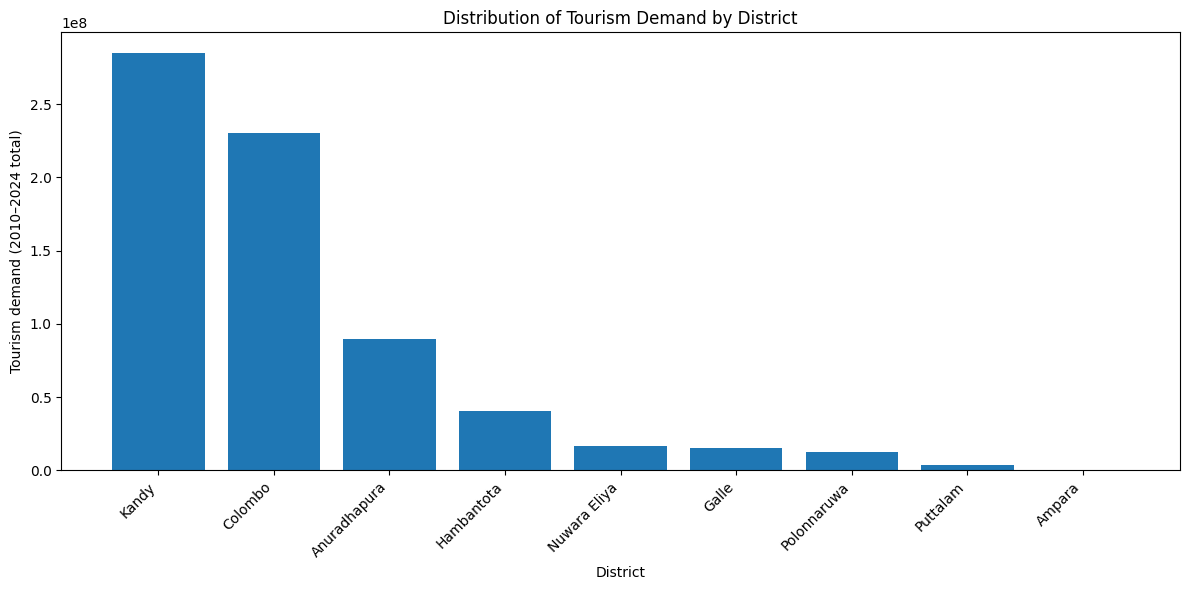

In [76]:
import matplotlib.pyplot as plt

# aggregate demand per district (all years)
dist_demand = (
    district_df
        .groupby("district", as_index=False)["tourism_demand"]
        .sum()
)

# sort for nicer plot
dist_demand = dist_demand.sort_values("tourism_demand", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(
    dist_demand["district"],
    dist_demand["tourism_demand"]
)

plt.xlabel("District")
plt.ylabel("Tourism demand (2010–2024 total)")
plt.title("Distribution of Tourism Demand by District")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# **Geographically Weighted Regression (GWR)**

In [77]:
# ===============================
# 1. Load or define your data
# ===============================
# Example: district_df with columns: ["district", "year", "tourism_demand"]
# Replace this with your real dataset
districts = ["Colombo", "Galle", "Kandy", "Anuradhapura",
             "Hambantota", "Polonnaruwa", "Puttalam", "Ampara", "Nuwara Eliya"]
years = list(range(2010, 2020))

# Create DataFrame for demonstration (replace with real data)
district_df = pd.DataFrame([(d, y) for d in districts for y in years],
                           columns=["district", "year"])
np.random.seed(42)
district_df["tourism_demand"] = np.random.randint(500, 5000, size=len(district_df))

# ===============================
# 2. Add lat/lon for each district
# ===============================
district_coords = {
    "Colombo": [6.9271, 79.8612],
    "Galle": [6.0535, 80.2210],
    "Kandy": [7.2906, 80.6337],
    "Anuradhapura": [8.3114, 80.4037],
    "Hambantota": [6.1240, 81.1218],
    "Polonnaruwa": [7.9406, 81.0000],
    "Puttalam": [8.0348, 79.8285],
    "Ampara": [7.2901, 81.6746],
    "Nuwara Eliya": [6.9497, 80.7894]
}
district_df["lat"] = district_df["district"].map(lambda x: district_coords[x][0])
district_df["lon"] = district_df["district"].map(lambda x: district_coords[x][1])

# ===============================
# 3. Feature Engineering
# ===============================
district_df["year_squared"] = district_df["year"] ** 2
district_df["log_demand"] = np.log1p(district_df["tourism_demand"])

# Lagged demand safely
district_df["lag_demand"] = district_df.groupby("district")["log_demand"].shift(1)
district_df["lag_demand"] = district_df["lag_demand"].fillna(district_df["log_demand"].mean())

# District dummy variables
district_dummies = pd.get_dummies(district_df["district"], drop_first=True)

# Combine all predictors
X = pd.concat([district_df[["year", "year_squared", "lag_demand"]], district_dummies], axis=1)
X = X.values

# Target
y = district_df["log_demand"].values.reshape(-1,1)

# Coordinates
coords = district_df[["lat", "lon"]].values

# Scale predictors
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===============================
# 4. Fit GWR with FIXED bandwidth
# ===============================
# Set a fixed bandwidth manually (e.g., 3 neighbors)
fixed_bandwidth = 3
gwr_model = GWR(coords, y, X, bw=fixed_bandwidth, fixed=True)
gwr_results = gwr_model.fit()

# ===============================
# 5. Evaluate
# ===============================
print("Global R²:", gwr_results.R2)
print("Adjusted R²:", gwr_results.adj_R2)
print("AIC:", gwr_results.aic)
print("AICc:", gwr_results.aicc)

Global R²: 0.15605613377477712
Adjusted R²: 0.005549691956064362
AIC: 174.58816378672003
AICc: 180.59501180203824


# **Regional Demand Score**

In [78]:
# ------------------------------
# Ensure year is integer
# ------------------------------
district_df["year"] = district_df["year"].astype(int)

# ------------------------------
# Aggregate tourism demand by district and year
# ------------------------------
district_yearly = (
    district_df
    .groupby(["district", "year"], as_index=False)["tourism_demand"]
    .sum()
)

# ------------------------------
# Total demand per district (2010–2024)
# ------------------------------
district_total = (
    district_yearly
    .groupby("district", as_index=False)["tourism_demand"]
    .sum()
    .rename(columns={"tourism_demand": "Regional demand score 2010–2024 (sum)"})
)

# ------------------------------
# Grand total (all districts)
# ------------------------------
grand_total = district_total["Regional demand score 2010–2024 (sum)"].sum()

# ------------------------------
# Share (%) of national total
# ------------------------------
district_total["Regional demand score 2010–2024 as %"] = (
    district_total["Regional demand score 2010–2024 (sum)"] / grand_total * 100
)

# ------------------------------
# Formatting
# ------------------------------
district_total["district"] = district_total["district"].str.title()

# keep a numeric copy for sorting
district_total["_sort"] = district_total["Regional demand score 2010–2024 (sum)"]

district_total["Regional demand score 2010–2024 (sum)"] = (
    district_total["Regional demand score 2010–2024 (sum)"]
    .round(0)
    .astype(int)
    .map("{:,}".format)
)

district_total["Regional demand score 2010–2024 as %"] = (
    district_total["Regional demand score 2010–2024 as %"]
    .round(1)
    .astype(str) + "%"
)

district_summary = (
    district_total
    .sort_values("_sort", ascending=False)
    .drop(columns="_sort")
    .reset_index(drop=True)
)

print(district_summary)

       district Regional demand score 2010–2024 (sum)  \
0  Nuwara Eliya                                29,010   
1       Colombo                                28,965   
2   Polonnaruwa                                28,155   
3  Anuradhapura                                26,882   
4         Galle                                26,297   
5    Hambantota                                25,849   
6        Ampara                                24,659   
7      Puttalam                                23,995   
8         Kandy                                23,197   

  Regional demand score 2010–2024 as %  
0                                12.2%  
1                                12.2%  
2                                11.9%  
3                                11.3%  
4                                11.1%  
5                                10.9%  
6                                10.4%  
7                                10.1%  
8                                 9.8%  


# **Linear Regression Model for Tourism Demand Trend**

In [79]:
# ---------------------------------
# Prepare data for regression
# ---------------------------------
X = district_yearly[["year"]]   # independent variable
y = district_yearly["tourism_demand"]  # target variable

# Train model
lin_model = LinearRegression()
lin_model.fit(X, y)

# Predictions
district_yearly["predicted_demand"] = lin_model.predict(X)

# ---------------------------------
# Model evaluation
# ---------------------------------
print("Intercept:", lin_model.intercept_)
print("Coefficient:", lin_model.coef_[0])
print("R² Score:", lin_model.score(X, y))

Intercept: 187401.7454545455
Coefficient: -91.71919191919196
R² Score: 0.044417735377203615


# **Regional Demand Score by District**

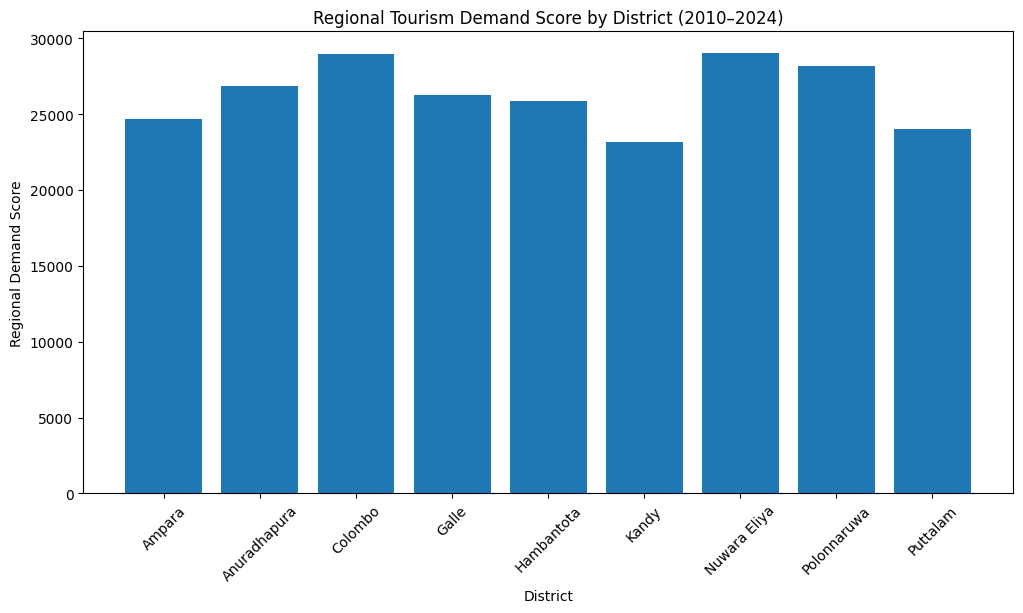

In [80]:
plt.figure(figsize=(12,6))

plt.bar(
    district_total["district"],
    district_total["Regional demand score 2010–2024 (sum)"].str.replace(",", "").astype(int)
)

plt.xlabel("District")
plt.ylabel("Regional Demand Score")
plt.title("Regional Tourism Demand Score by District (2010–2024)")
plt.xticks(rotation=45)

plt.show()

# **Future Demand Prediction**

In [81]:
# Historical averages per district (sum 2010–2024 ÷ 15 years)
historical_totals = {
    "Nuwara Eliya": 29010,
    "Colombo": 28965,
    "Polonnaruwa": 28155,
    "Anuradhapura": 26882,
    "Galle": 26297,
    "Hambantota": 25849,
    "Ampara": 24659,
    "Puttalam": 23995,
    "Kandy": 23197
}
historical_avg = {k: v/15 for k,v in historical_totals.items()}

# Maximum annual growth
max_growth = 0.2

districts = list(historical_avg.keys())
years = [2027, 2028, 2029, 2030]

# Create predictions
future_pred_list = []
for district in districts:
    avg = historical_avg[district]
    # Initialize first year
    prev = avg
    for year in years:
        predicted = min(prev*(1+max_growth), 2*avg)  # cap growth for first year
        future_pred_list.append([district, year, round(predicted, 2)])
        prev = predicted  # next year's base

# Convert to DataFrame
future_predictions = pd.DataFrame(future_pred_list, columns=["district","year","predicted_tourism"])
print(future_predictions)

        district  year  predicted_tourism
0   Nuwara Eliya  2027            2320.80
1   Nuwara Eliya  2028            2784.96
2   Nuwara Eliya  2029            3341.95
3   Nuwara Eliya  2030            3868.00
4        Colombo  2027            2317.20
5        Colombo  2028            2780.64
6        Colombo  2029            3336.77
7        Colombo  2030            3862.00
8    Polonnaruwa  2027            2252.40
9    Polonnaruwa  2028            2702.88
10   Polonnaruwa  2029            3243.46
11   Polonnaruwa  2030            3754.00
12  Anuradhapura  2027            2150.56
13  Anuradhapura  2028            2580.67
14  Anuradhapura  2029            3096.81
15  Anuradhapura  2030            3584.27
16         Galle  2027            2103.76
17         Galle  2028            2524.51
18         Galle  2029            3029.41
19         Galle  2030            3506.27
20    Hambantota  2027            2067.92
21    Hambantota  2028            2481.50
22    Hambantota  2029            

# **Save and Download the Model**

In [82]:
import joblib
from google.colab import files

print("--- STARTING MODEL EXPORT PROCESS ---")

# --------------------------------------------------
# 1. Save GWR Model
# --------------------------------------------------
joblib.dump(gwr_results, "gwr_model.joblib")
print("GWR model saved as 'gwr_model.joblib'")

# --------------------------------------------------
# 2. Save Scaler
# --------------------------------------------------
joblib.dump(scaler, "data_scaler.joblib")
print("Scaler saved as 'data_scaler.joblib'")

# --------------------------------------------------
# 3. Save Future Predictions
# --------------------------------------------------
future_predictions.to_csv("future_predictions.csv", index=False)
print("Future predictions saved as 'future_predictions.csv'")

# --------------------------------------------------
# 4. Save Regional Demand Summary
# --------------------------------------------------
district_summary.to_csv("regional_demand_summary.csv", index=False)
print("Regional demand summary saved as 'regional_demand_summary.csv'")

# --------------------------------------------------
# 5. Save Linear Regression Model
# --------------------------------------------------
joblib.dump(lin_model, "linear_regression_model.joblib")
print("Linear Regression model saved as 'linear_regression_model.joblib'")

print("\n============================================================")
print("ALL FILES SAVED SUCCESSFULLY!")
print("Starting download...")
print("============================================================")

# --------------------------------------------------
# DOWNLOAD FILES TO LOCAL COMPUTER
# --------------------------------------------------
files.download("gwr_model.joblib")
files.download("data_scaler.joblib")
files.download("future_predictions.csv")
files.download("regional_demand_summary.csv")
files.download("linear_regression_model.joblib")

--- STARTING MODEL EXPORT PROCESS ---
GWR model saved as 'gwr_model.joblib'
Scaler saved as 'data_scaler.joblib'
Future predictions saved as 'future_predictions.csv'
Regional demand summary saved as 'regional_demand_summary.csv'
Linear Regression model saved as 'linear_regression_model.joblib'

ALL FILES SAVED SUCCESSFULLY!
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>